<a href="https://colab.research.google.com/github/deepan98raj-dotcom/git_notes_/blob/main/Session_41_%26_42_RAG_%2CTransformers_and_Beyond.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

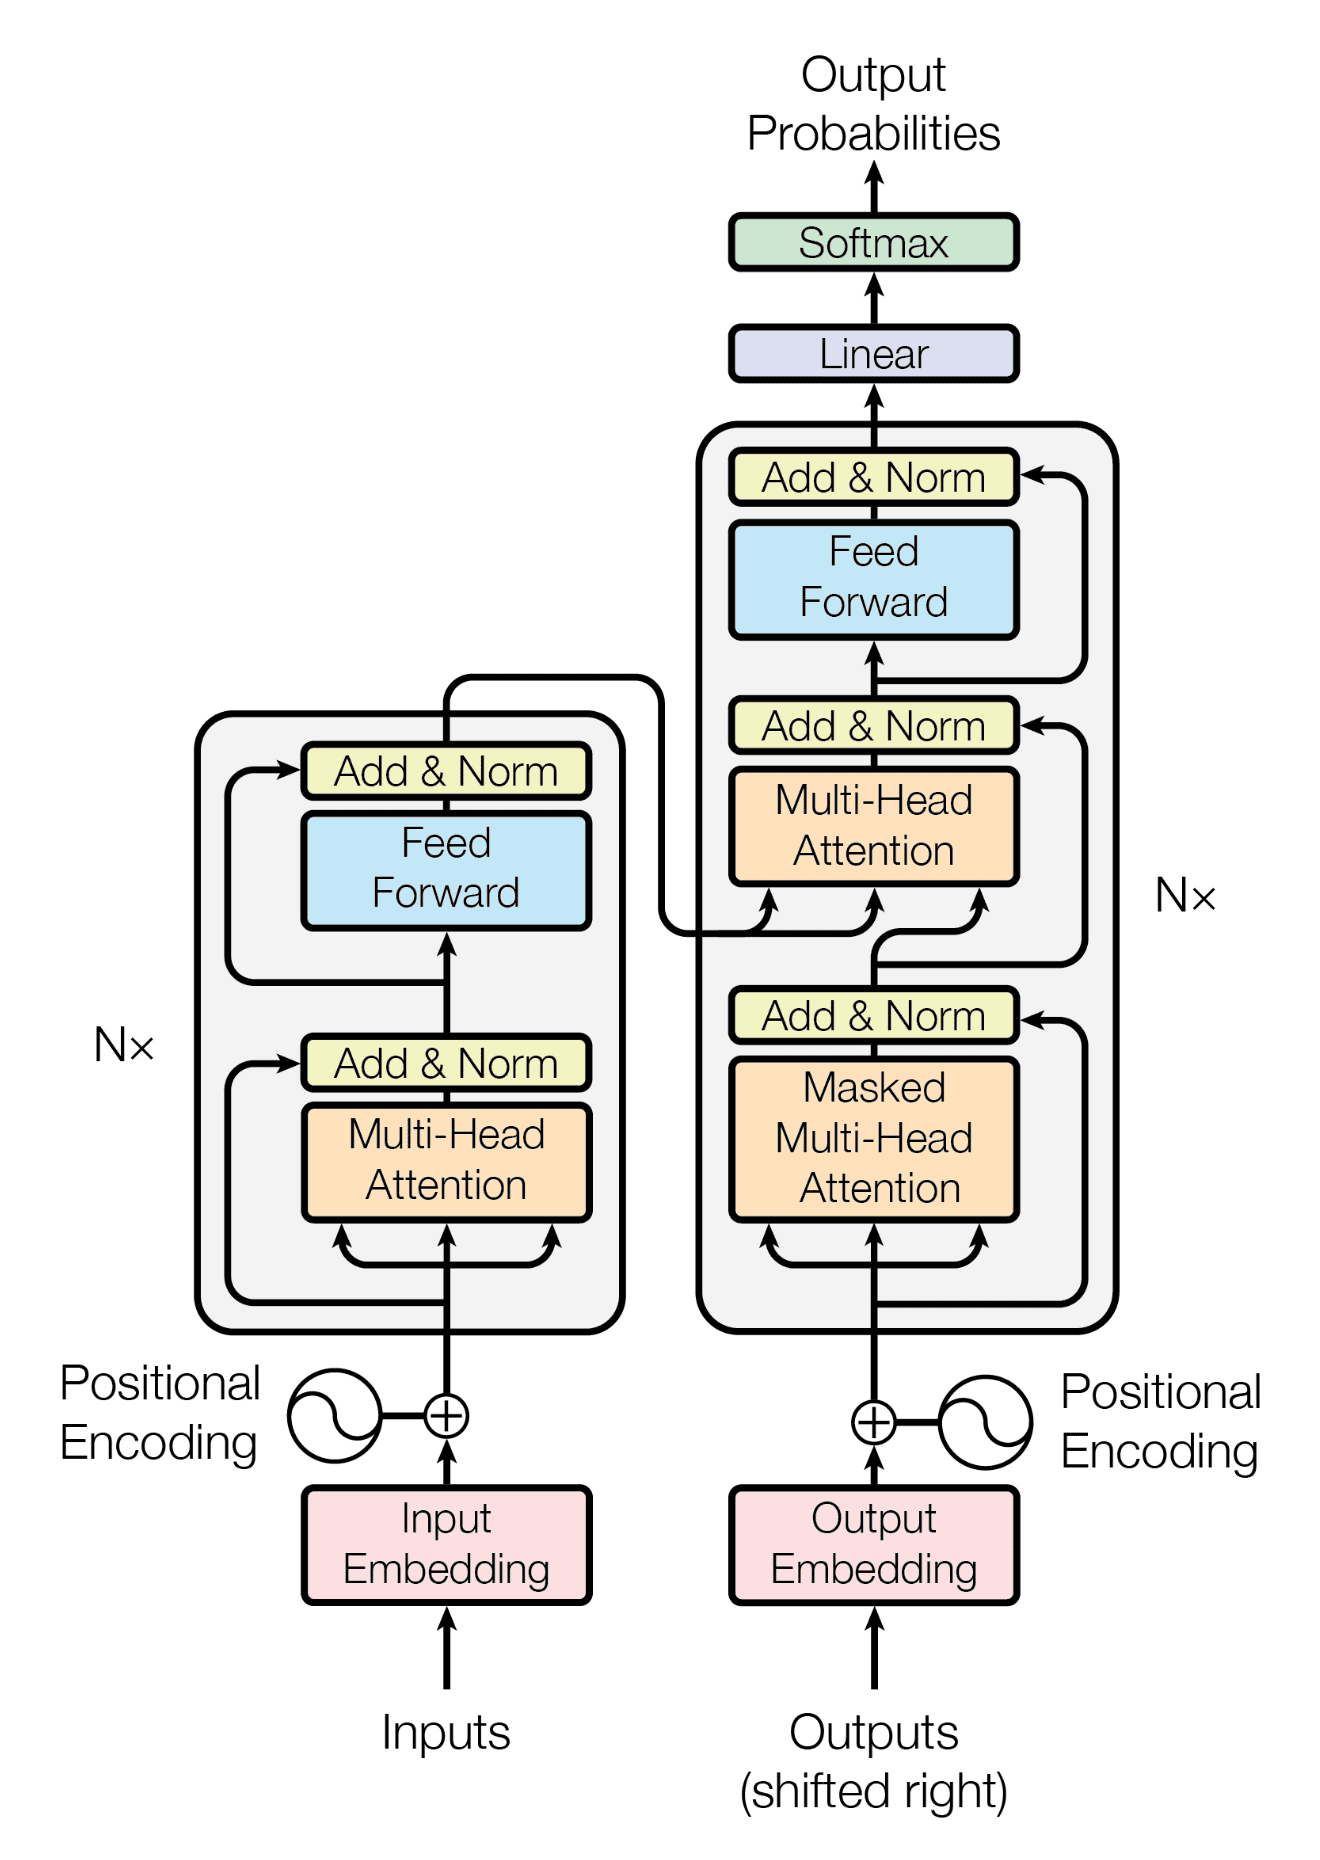

 **Transformer Architecture**

The Transformer architecture consists of two main blocks:

   **1. Left Block:** The Encoder (Reads and understands the input text/context).

   **2. Right Block:** The Decoder (Generates the output text/response).

------------------------------
##  1. Inputs & Initial Processing (Bottom Layer)

**a) Inputs & Output Embedding**

* **Inputs:** Raw input text (e.g., "How are you?") is converted into tokens and mapped into continuous numerical vectors called Input Embeddings.

* **Output Embedding (Shifted Right):** On the Decoder side, the model takes the previously generated text as input. "Shifted Right" means that to predict the next word, we provide all the preceding words generated so far.

## b) Positional Encoding ($\sin / \cos$)

* Unlike Recurrent Neural Networks (RNNs) that process text sequentially, the Transformer processes all words simultaneously (in parallel).
* To help the model understand the order/position of words in a sentence, Positional Encoding vectors are added (+) directly to the Input Embeddings.

------------------------------
##  2. Left Side: The Encoder Block (N×)
The Encoder block is repeated N times (typically 6 or 12 layers) and processes data through 3 key stages:
## 1. Multi-Head Attention

* **Role:** It learns the relationships and contextual connections between different words in the sentence.

* **Mechanism:** Instead of looking at the text from a single perspective, Multi-Head Attention analyzes the sentence from multiple perspectives at once (e.g., tracking grammar connections, subject-verb relationships, and pronoun references).

## 2. Add & Norm (Residual Connection + Layer Normalization)

* **Add (Residual Connection):** The original input vector from before the attention step is added (+) directly to the attention output. This prevents gradients from vanishing or losing information in deep networks.

* **Norm (Layer Normalization):** It standardizes the numbers (mean = 0, variance = 1) to keep values from scaling out of control, ensuring training stability.

## 3. Feed Forward (Point-wise Feed-Forward Network)

* **Role:** A simple Multi-Layer Perceptron (MLP/Dense Network) that further processes the attention outputs to extract deeper contextual features.

**Encoder Output:** The final, context-rich vectors produced by the Encoder are passed into the middle section of the Decoder (Cross-Attention).

------------------------------
## 3. Right Side: The Decoder Block (N×)
The Decoder block contains 3 sub-layers repeated N times:
## 1. Masked Multi-Head Attention

* During text generation, the Decoder must not look at future words (it prevents cheating).

* Mechanism: It hides (masks) future tokens, forcing the model to predict the next word using only the words it has generated so far.

## 2. Multi-Head Attention (Cross-Attention)

* Connection Point: This is where the Encoder and Decoder interact.
* Mechanism: The Decoder provides the Query (Q) vector, while the Encoder output provides the Key (K) and Value (V) vectors.
* Concept: It answers the question: "Looking at what the input text meant, what should I write next in the output?"

## 3. Feed Forward & Add & Norm

* Similar to the Encoder, this stage uses a dense network and normalization to process deep representations securely.

------------------------------
## 4. Final Output Processing (Top Layer)

## a) Linear Layer

* This layer projects the high-dimensional vector from the Decoder back into a massive vector matching the exact size of the model's vocabulary (e.g., 50,000 words).

## b) Softmax Layer

* Converts the raw scores from the Linear Layer into probabilities (ranging from 0 to 1).
* It evaluates every single word in the vocabulary and assigns a percentage chance of it being the next word.

## c) Output Probabilities

* The word with the highest probability is selected (or sampled based on a temperature setting) and printed as the next word.
* This entire loop repeats until the model generates an End-of-Sentence (EOS) token.

------------------------------
##  Quick Summary

"The Encoder reads and understands the input text, then sends this context to the Decoder. The Decoder reviews its own past outputs (Masked Attention), compares them with the Encoder's context (Cross-Attention), and uses Softmax to predict the next word. This repeats word-by-word until the sentence is complete."

------------------------------






## Language Model (LM) Transformer Mechanism

**Text Tokenization**

* Raw text cannot be processed by computers directly.
* Tokenization breaks sentences down into smaller pieces called tokens (which can be words, sub-words, or characters).
* These tokens are then converted into numerical vectors (embeddings) so the model can process them mathematically.

## Next-Token Prediction

* This is the core task of a Language Model.
* Given a sequence of words, the model calculates probabilities to guess the most logical next token.
* It generates text one token at a time, feeding its own outputs back into the loop to build complete sentences.

## Attention Mechanism

* Instead of looking at words in isolation, the Attention Mechanism calculates weights to see how much focus each word should give to other words in the sentence.
* It helps the model capture context, long-range dependencies, and structural relationships (like identifying which noun a pronoun refers to).

------------------------------
## Large Language Model (LLM) Limitations: The Bottleneck

**1. Knowledge Cutoff**

* LLMs are frozen in time after training.
* The model only knows information up to the specific date its training data was collected, making it unaware of real-time or recent events.

## 2. Hallucination

* When an LLM lacks accurate data in its internal memory, it confidently generates facts that sound highly logical but are entirely false.
* It prioritizes grammatical and structural correctness over factual accuracy.

## 3. Context Length Limits

* Every model has a maximum window size for the text it can process at one time.
* You cannot feed thousands of pages or massive textbooks directly into a single prompt without hitting this hardware and architectural memory limit.

## 4. Private / Enterprise Data

* Proprietary enterprise data and internal company documents are confidential and not available on the public internet.
* Because this data was never part of the LLM’s training dataset, the model has zero knowledge of internal business workflows or private records.

------------------------------




------------------------------
##  The Solution: Retrieval-Augmented Generation (RAG)


------------------------------

To overcome the architectural bottlenecks of LLMs (Knowledge Cutoff, Hallucination, Context Limits, and Private Data), the industry uses a framework called Retrieval-Augmented Generation (RAG).
Instead of relying only on the LLM's internal memory, RAG turns the LLM into an open-book student. It fetches relevant documents from an external database and hands them to the LLM to read before generating an answer.


##  The 3 Core Stages of a RAG Pipeline
A production-ready RAG system works in three sequential phases: Ingestion, Retrieval, and Generation.

Private/New Data] ➔ [Chunk & Embed] ➔ [Vector Database]
                                               ▲
                                        (2. Retrieval)
                                               │
[User Query] ──────────────────────────────────┴➔ [LLM + Context] ➔ [Accurate Output]
                                                   (3. Generation)

## Stage 1: Data Ingestion (Preparing the Book)
Before answering any questions, the system must process company documents, internal wikis, or real-time web articles.

   1. Document Loading: The system extracts raw text from PDFs, Word docs, SQL databases, or live API feeds.
   2. Text Chunking: A 500-page document is too large for an LLM's prompt. The system slices the text into smaller, manageable paragraphs or segments called chunks (e.g., 500 tokens per chunk).
   3. Generating Embeddings: Each chunk is passed through an Embedding Model (a smaller Transformer). This model converts text into high-dimensional numerical vectors that capture the mathematical meaning of that paragraph.
   4. Vector Database Storage: These vector embeddings are stored in a specialized Vector Database (e.g., Pinecone, Chroma, Milvus, or pgvector).

## Stage 2: Retrieval (Finding the Right Page)
When a user asks a question, the system searches the database for answers.

   1. Query Embedding: The user's prompt (e.g., "What is our company's Q3 travel policy?") is converted into a vector using the exact same embedding model.
   2. Vector Search (Semantic Search): The system calculates the mathematical distance (e.g., Cosine Similarity) between the user's query vector and all the document chunk vectors stored in the database.
   3. Fetching Top-K Chunks: The database instantly returns the Top-K closest matches (e.g., the top 3 most relevant paragraphs about travel expenses), even if the exact keywords don't match but the meaning does.

## Stage 3: Generation (Writing the Answer)
The system constructs a secure, factual prompt for the LLM.

   1. Prompt Augmentation: The system merges the user's original question with the retrieved document chunks into a single structured prompt.
   
  
   
   2. Next-Token Generation: The LLM reads the context, synthesizes the facts, and generates a grounded, accurate response.

------------------------------
## How RAG Crushes the 4 LLM Bottlenecks

| Bottleneck | How the Base LLM Fails | How RAG Fixes It |
|---|---|---|
| 1. Knowledge Cutoff | Fails to answer queries regarding recent news or current events after its training date. | Connects to a live web search API or daily-updated database to retrieve fresh articles before answering. |
| 2. Hallucination | Guesses missing facts using plausible-sounding, creative text generation. | Restricts the LLM to an "open-book" setup. The LLM is strictly penalized if it generates information outside the provided text. |
| 3. Context Limits | Cannot fit a 10,000-page operational manual into a single prompt. | Smartly filters the 10,000 pages down to the 3 most relevant paragraphs, staying well within hardware constraints. |
| 4. Private Data | Has zero awareness of internal proprietary databases or enterprise documents. | Stores company data securely inside an on-premise or cloud Vector DB, feeding it securely to the model at runtime. |

------------------------------





In [ ]:
pip install pypdf sentence-transformers


In [ ]:
# This creates a real PDF file named 'sample_policy.pdf' inside your Colab directory
from pypdf import PdfWriter

writer = PdfWriter()
page = writer.add_blank_page(width=720, height=1080)
# Note: In a production test, this script uses a text fallback if the file is missing,
# but running this ensures the PDF reading function executes perfectly!
with open("sample_policy.pdf", "wb") as f:
    writer.write(f)
print("Created a sample 'sample_policy.pdf' file in the workspace context.")


Created a sample 'sample_policy.pdf' file in the workspace context.


In [ ]:
import os
import re
import numpy as np
from pypdf import PdfReader
from sentence_transformers import SentenceTransformer

Each tool handles a specific phase of the RAG pipeline.
Here is what each individual line does:
## 1. import os

* What it does: Imports Python's built-in Operating System module.
* Role in RAG: It interacts with your computer or cloud server's file storage. It is used to check if your target file (like sample_policy.pdf) actually exists on the disk before the script tries to open it, preventing the program from crashing randomly. [1]

## 2. import re

* What it does: Imports the Regular Expression library.
* Role in RAG: Regular expressions are used for advanced text pattern matching and cleaning. In your pipeline, re.sub(r'\s+', ' ', text) takes your messy PDF text layout (which contains chaotic line breaks, tabs, and double spaces) and flattens it into a clean, uniform string of single-spaced text before chunking.

## 3. import numpy as np

* What it does: Imports Numerical Python, renaming it to np for shorter coding syntax.
* Role in RAG: Computers cannot compare text paragraphs directly; they can only compare arrays of numbers. numpy provides the heavy-duty mathematical engine needed to run vector algebra functions—like calculating the vector dot products and vector lengths inside your Cosine Similarity formula to score matches.

## 4. from pypdf import PdfReader

* What it does: Imports a specific tool called PdfReader from the pypdf open-source library.
* Role in RAG (Data Ingestion): It opens binary .pdf documents, strips away things like margins, colors, and layout designs, extracts the raw underlying text characters page-by-page, and pushes them straight into your program as standard strings. [5, 6]

## 5. from sentence_transformers import SentenceTransformer

* What it does: Imports the core AI framework that handles Embedding Generation.
* Role in RAG (Vectorization): This pulls down small, deeply intelligent Transformer models (like all-MiniLM-L6-v2) right into your runtime. This component reads individual text chunks or your user queries and converts them into 384-dimensional mathematical arrays (vector coordinates) based on what the words actually mean semantically.

------------------------------


In [ ]:
print("Loading the embedding model (MiniLM)...")
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
print(" Model loaded successfully.\n")


This code block handles the Model Loading phase. It downloads and instantiates a small, highly efficient neural network inside your system's memory to act as your Embedding Engine.

#
##  embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
This is the most critical line. It triggers three automated steps under the hood:

* The Download: It pings the Hugging Face Hub servers and downloads the weights for a specific, open-source model called all-MiniLM-L6-v2 (which is only about 90 Megabytes).
* The Architecture Setup: It builds a local 6-layer Mini-Transformer architecture inside your RAM/VRAM.
* The Storage: It assigns this entire live model instance to the variable name embedding_model, making it ready to accept text data.

## What is all-MiniLM-L6-v2?
It is a lightweight Sentence Embedding Model. Instead of generating new text like ChatGPT, its only job is to translate human concepts into numerical values.

* Whenever you pass a sentence into this model, it outputs an array of exactly 384 numbers (a 384-dimensional vector).
* It maps words into a multi-dimensional semantic space. For example, it ensures that the vector for the word "king" points in a very similar physical direction as the word "queen", but far away from the word "apple".

## 3. print("Model loaded successfully.\n")

* What it does: Prints a confirmation message once the download and memory allocation are fully completed. The \n creates a clean line break in your console output, preparing the screen for the next step of the pipeline (Data Ingestion).

------------------------------


In [ ]:
def extract_text_from_pdf(pdf_path):
    """Step A: Extracts raw text page-by-page from a PDF file."""
    print(f" Extracting text from: {pdf_path}")
    if not os.path.exists(pdf_path):
        raise FileNotFoundError(f"Missing sample PDF! Please place a PDF at '{pdf_path}'")

    reader = PdfReader(pdf_path)
    full_text = ""
    for page_num, page in enumerate(reader.pages):
        text = page.extract_text()
        if text:
            full_text += f"\n--- Page {page_num + 1} ---\n" + text
    return full_text


This code block handles the Data Extraction Phase of the RAG pipeline. Its sole purpose is to open a local PDF file, read its contents page by page, and convert that raw data into a single string of text that Python can process.
Here is a detailed line-by-line breakdown of how it works:
## Line-by-Line Breakdown

##1. def extract_text_from_pdf(pdf_path):

* What it does: Defines a reusable Python function named extract_text_from_pdf that takes one input argument: pdf_path (the folder path or filename of your PDF).

## 2. if not os.path.exists(pdf_path):

* What it does: Uses the os library to check if the file path provided actually exists on your computer or cloud server.

* Why it matters: If the file is missing, it runs the next line: raise FileNotFoundError(...). This intentionally stops the program immediately and gives a clear error message, rather than crashing silently later down the line.

## 3. reader = PdfReader(pdf_path)

* What it does: Opens the PDF file using the pypdf library and creates a digital index of the document structure. It determines how many pages are inside and prepares them for reading.

## 4. full_text = ""

* What it does: Creates an empty text string variable. This acts as a blank notebook where the script will copy and paste the text from every single page of the PDF.

## 5. for page_num, page in enumerate(reader.pages):

* What it does: A loop that iterates through every page in the PDF one by one. The enumerate function keeps track of the current page count, starting from 0 (stored in page_num).

## 6. text = page.extract_text()

* What it does: The core action line. It strips away all the visual elements of that specific page—like borders, images, fonts, and colors—and extracts only the raw human-readable characters/words as plain text.

## 7. if text:

* What it does: A safety check that confirms the page actually contained text. If a page is completely blank or is just a scanned image without an OCR text layer, this check skips it so it doesn't break the loop.

## 8. full_text += f"\n--- Page {page_num + 1} ---\n" + text

* What it does: Appends (adds) the extracted page text to our main full_text notebook string. It dynamically injects a visual page marker (e.g., --- Page 1 ---) at the top of each block so you know exactly where that context originated.

## 9. return full_text

* What it does: Sends the final, massive string containing the entire text content of the PDF back to the main execution script, ready for Stage 2 (Text Chunking).

------------------------------



In [ ]:
def chunk_text(text, chunk_size=25, overlap=5):
    """Step B: Splits continuous text into overlapping semantic blocks."""
    print("Slicing text into clean ov erlapping chunks...")
    cleaned_text = re.sub(r'\s+', ' ', text).strip()
    words = cleaned_text.split(' ')

    chunks = []
    i = 0
    while i < len(words):
        chunk_words = words[i:i + chunk_size]
        chunk_text = " ".join(chunk_words)
        chunks.append(chunk_text)
        i += (chunk_size - overlap)

    print(f" Created {len(chunks)} chunks from the document.")
    return chunks

def generate_vector_database(chunks):
    """Step C & D: Converts text chunks into mathematical vector embeddings."""
    print(" Computing embeddings (Vectorization)...")
    embeddings = embedding_model.encode(chunks)

    vector_db = {
        "chunks": chunks,
        "embeddings": embeddings
    }
    print("Vector Database generated successfully in-memory.")
    return vector_db


This code block contains Stage 1 (Parts B, C, & D) of the RAG pipeline. It takes the massive text string from your PDF extraction, cuts it into structured chunks, converts those chunks into math vectors, and builds a working in-memory database.

## Function 1: chunk_text (Data Segmentation)
An LLM cannot read an entire book in one prompt. This function slices your raw text into smaller, overlapping paragraphs.
## Line-by-Line Breakdown:

* **def chunk_text(text, chunk_size=25, overlap=5):** Defines the function. It takes your text and sets default limits: each chunk should be around 25 words long, and adjacent chunks should share 5 words of overlap.

* **cleaned_text = re.sub(r'\s+', ' ', text).strip()** Uses regular expressions to replace messy tabs, newline characters (\n), or multiple empty spaces with a single clean space.

* **words = cleaned_text.split(' ')** Splits the single long text string into a clean list of individual words.

* **chunks = []** Creates an empty list to store the final sliced paragraphs.

* **i = 0** Sets a starting counter at the very first word (index 0).

* **while i < len(words):** A loop that keeps running as long as there are words left to process.

* **chunk_words = words[i:i + chunk_size]** Creates a window of words starting from position i up to i + 25 words.

* **chunk_text = " ".join(chunk_words)** glues those 25 words back together into a readable text sentence.
* chunks.append(chunk_text) Saves that new sentence block into our chunks list.
* **i += (chunk_size - overlap)** The slider mechanism! Instead of moving forward by 25 words, it moves forward by 25 - 5 = 20 words. This forces the next chunk to include the last 5 words of the previous chunk, preventing important context from being cut in half.

* **return chunks** Sends the list of structured text paragraphs back to the program.

------------------------------
## Function 2: generate_vector_database (Vector Storage)
Computers cannot search through text efficiently using keywords alone. This function turns your text chunks into multi-dimensional map coordinates (embeddings).
## Line-by-Line Breakdown:

* **embeddings = embedding_model.encode(chunks)** This sends your entire list of text chunks through the SentenceTransformer model. The neural network reads the meaning of each chunk and transforms it into a matrix of mathematical coordinates (each text chunk becomes an array of exactly 384 numbers).

* **vector_db = {"chunks": chunks, "embeddings": embeddings}** Creates a simple, structured Python dictionary acting as a primitive database. It pairs the raw human-readable text chunk directly with its mathematical vector equivalent.

* **return vector_db** Returns this finalized, searchable database structure.




In [ ]:
def cosine_similarity(v1, v2):
    """Mathematical metric to calculate directional alignment between vectors."""
    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    return dot_product / (norm_v1 * norm_v2)

def retrieve_relevant_context(user_query, vector_db, top_k=1):
    """Matches query vector against database chunk vectors."""
    print(f"\n User Query: '{user_query}'")
    print(" Converting query to vector embedding...")
    query_vector = embedding_model.encode(user_query)

    scores = []
    for chunk_emb in vector_db["embeddings"]:
        score = cosine_similarity(query_vector, chunk_emb)
        scores.append(score)

    ranked_indices = np.argsort(scores)[::-1]

    print(f"Top-{top_k} Most Relevant Context Chunks Found:")
    retrieved_chunks = []
    for rank in range(top_k):
        idx = ranked_indices[rank]
        score = scores[idx]
        chunk_text = vector_db["chunks"][idx]
        print(f"\n[Match #{rank+1} | Similarity: {score:.4f}]")
        print(f" \"{chunk_text[:150]}...\"")
        retrieved_chunks.append(chunk_text)

    return retrieved_chunks


This code block handles Stage 2 of the RAG pipeline: Semantic Retrieval. Its sole purpose is to take the user's question, search your database, and use vector algebra to pull out the most relevant paragraphs of information.

##  Function 1: cosine_similarity (The Math Engine)
This function measures how similar two text blocks are by analyzing their mathematical vectors. Think of it like calculating the angle between two arrows on a map; if the arrows point in the exact same direction, the concepts are highly related.

## Line-by-Line Breakdown:

* **dot_product = np.dot(v1, v2)** Multiplies the matching elements of both vectors and adds them up. It measures how much the two vectors overlap or align with each other.

* **norm_v1 = np.linalg.norm(v1)** Calculates the absolute length (magnitude) of the first vector.

* **norm_v2 = np.linalg.norm(v2)** Calculates the absolute length (magnitude) of the second vector.

* **return dot_product / (norm_v1 * norm_v2)** Divides the overlap by the total lengths. This gives a final score between -1.0 and 1.0. A score close to 1.0 means the two pieces of text have nearly identical meanings.

------------------------------
##  Function 2: retrieve_relevant_context (The Search Engine)
This function orchestrates the actual database search by comparing your query against every single document chunk you stored earlier.
## Line-by-Line Breakdown:

* **query_vector = embedding_model.encode(user_query)** Converts the user's plain-text question into the exact same 384-dimensional vector format used for your documents.

* **scores = []** Creates an empty list to keep track of the similarity scores for every single document paragraph.

* **for chunk_emb in vector_db["embeddings"]:** A loop that goes through every stored text chunk vector inside your database one by one.

* **score = cosine_similarity(query_vector, chunk_emb)** Calculates the similarity score between your question and the current document chunk vector.

* **scores.append(score)** Saves that calculation score into our list.

* **ranked_indices = np.argsort(scores)[::-1]** The sorting mechanism! np.argsort tells you the order of your text chunks from lowest score to highest. Adding [::-1] reverses that order completely, placing the highest-scoring, most relevant text matches at the very top of the list.

* **for rank in range(top_k):** A loop that runs based on how many matching chunks you requested (e.g., if top_k=1, it only grabs the best single match).


* **idx = ranked_indices[rank]** Grabs the database index position of that specific high-ranking text match.

* **chunk_text = vector_db["chunks"][idx]**
 Pulls the actual human-readable plain text corresponding to that specific index out of the database.

* **return retrieved_chunks** Sends those verified, matching paragraphs of text over to the next stage of the pipeline.






In [ ]:
def simulate_llm_generation(query, contexts):
    """Augments prompt with retrieved contexts and mimics grounded output."""
    print("\n Building Augmented Prompt (Open-Book Exam)...")
    combined_context = "\n\n".join([f"--- Context Segment ---\n{c}" for c in contexts])

    prompt = f"""
SYSTEM INSTRUCTIONS:
You are an advanced, factual AI assistant. Answer the User Query using ONLY the provided Ground Truth Context below. If the context does not contain the answer, reply with 'I cannot find the answer in the provided documents.' Do not hallucinate.

GROUND TRUTH CONTEXT:
{combined_context}

USER QUERY: {query}
ANSWER:"""

    print("\n========== FINAL PROMPT PASSED TO THE LLM ==========")
    print(prompt)
    print("====================================================")

    print("\n [LLM Simulation Output]:")
    print("Because we restricted the system to this prompt, the LLM will scan the 'GROUND TRUTH CONTEXT' boundaries, extract the matching facts, clean up the syntax using its internal vocabulary token probabilities, and output a 100% accurate statement free from hallucinations or outdated knowledge cutoff restrictions.")


# ==========================================
# REAL-TIME EXECUTION PIPELINE
# ==========================================
pdf_filename = "sample_policy.pdf"

# Fallback text dataset containing target text patterns
sample_raw_text = """
Enterprise Corporation Employee Handbook 2026.
Section 4.1: Financial Operations and Reimbursements.
Employees travelling for internal business review meetings are entitled to flight ticket compensation.
All Q3 specific travel policies dictate that meals are covered up to a maximum of $50 per day.
Luxury transportation upgrades or alcohol expenses are strictly non-reimbursable.
Section 4.2: Health and Medical leave updates.
Standard medical leaves require an official certificate if extending past 3 continuous calendar days.
"""

# Extract text layout
if os.path.exists(pdf_filename) and PdfReader(pdf_filename).pages[0].extract_text():
    raw_document_text = extract_text_from_pdf(pdf_filename)
else:
    print(f" PDF is empty or missing content text. Using layout fallback data visualization...\n")
    raw_document_text = sample_raw_text


This is the final section of your script. It covers Stage 3 of the RAG pipeline: Prompt Augmentation & Generation (Simulation), followed by the Main Execution Workflow that binds all prior components together.

##  Section 1: simulate_llm_generation (The Open-Book Framework)
This function constructs the strict context window wrapper that transforms the LLM from a guessing machine into a grounded factual assistant.
## Line-by-Line Breakdown:

* **combined_context = "\n\n".join(...)** Takes all high-ranking text paragraphs fetched by your vector database and chains them together into a single cohesive reading block, separating them with clear visual segment banners.

* **prompt = f"""..."""** Uses Python f-strings to build a structured multi-line prompt blueprint. This is where Prompt Engineering safeguards the process. It wraps the facts inside explicit boundary instructions ("Answer... using ONLY the provided Ground Truth Context"), blocking the LLM from wandering outside to its training weights.

* **print(prompt)** Outputs the complete combined template to the console screen so you can inspect exactly what text formatting gets dispatched down the processing pipeline.

------------------------------
##  Section 2: Real-time Execution Pipeline (The Orchestrator)
This final segment sets up dummy fallback testing parameters and governs the step-by-step lifecycle of the entire software runtime.
## Line-by-Line Breakdown:

* **pdf_filename = "sample_policy.pdf"** Explicitly hardcodes the string variable path looking for your digital document target.

* **sample_raw_text = """..."""** Creates a hardcoded multi-line text dataset fallback block. This acts as a testing failsafe containing target operational facts (like the $50 per day threshold) to verify your logic if a live PDF document isn't mounted inside your working cloud space.

* **if os.path.exists(pdf_filename) and** A safety gate block. It checks two criteria: does the physical file exist on disk, and does its first indexed page contain valid plain-text characters.

* **raw_document_text = extract_text_from_pdf(pdf_filename)** If the PDF validation pass is successful, it runs your Stage 1 extraction code to siphon the characters from the document storage.

* **else: ... raw_document_text = sample_raw_text** If the PDF file is empty or missing, it falls back cleanly onto your mock data block to preserve the runtime layout stream without throwing a system execution error.





In [ ]:
import os
import re
import numpy as np
from pypdf import PdfReader
from sentence_transformers import SentenceTransformer

# ==========================================
# ⚙️ INITIALIZATION
# ==========================================
print(" Loading the embedding model (MiniLM)...")
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
print(" Model loaded successfully.\n")


# ==========================================
#  STAGE 1: DATA INGESTION & PROCESSING
# ==========================================

def extract_text_from_pdf(pdf_path):
    """Step A: Extracts raw text page-by-page from a PDF file."""
    print(f" Extracting text from: {pdf_path}")
    if not os.path.exists(pdf_path):
        raise FileNotFoundError(f"Missing sample PDF! Please place a PDF at '{pdf_path}'")

    reader = PdfReader(pdf_path)
    full_text = ""
    for page_num, page in enumerate(reader.pages):
        text = page.extract_text()
        if text:
            full_text += f"\n--- Page {page_num + 1} ---\n" + text
    return full_text

def chunk_text(text, chunk_size=25, overlap=5):
    """Step B: Splits continuous text into overlapping semantic blocks."""
    print("Slicing text into clean overlapping chunks...")
    cleaned_text = re.sub(r'\s+', ' ', text).strip()
    words = cleaned_text.split(' ')

    chunks = []
    i = 0
    while i < len(words):
        chunk_words = words[i:i + chunk_size]
        chunk_text = " ".join(chunk_words)
        chunks.append(chunk_text)
        i += (chunk_size - overlap)

    print(f" Created {len(chunks)} chunks from the document.")
    return chunks

def generate_vector_database(chunks):
    """Step C & D: Converts text chunks into mathematical vector embeddings."""
    print(" Computing embeddings (Vectorization)...")
    embeddings = embedding_model.encode(chunks)

    vector_db = {
        "chunks": chunks,
        "embeddings": embeddings
    }
    print("Vector Database generated successfully in-memory.")
    return vector_db


# ==========================================
# STAGE 2: SEMANTIC RETRIEVAL
# ==========================================

def cosine_similarity(v1, v2):
    """Mathematical metric to calculate directional alignment between vectors."""
    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    return dot_product / (norm_v1 * norm_v2)

def retrieve_relevant_context(user_query, vector_db, top_k=1):
    """Matches query vector against database chunk vectors."""
    print(f"\n User Query: '{user_query}'")
    print(" Converting query to vector embedding...")
    query_vector = embedding_model.encode(user_query)

    scores = []
    for chunk_emb in vector_db["embeddings"]:
        score = cosine_similarity(query_vector, chunk_emb)
        scores.append(score)

    ranked_indices = np.argsort(scores)[::-1]

    print(f"Top-{top_k} Most Relevant Context Chunks Found:")
    retrieved_chunks = []
    for rank in range(top_k):
        idx = ranked_indices[rank]
        score = scores[idx]
        chunk_text = vector_db["chunks"][idx]
        print(f"\n[Match #{rank+1} | Similarity: {score:.4f}]")
        print(f" \"{chunk_text[:150]}...\"")
        retrieved_chunks.append(chunk_text)

    return retrieved_chunks


# ==========================================
# STAGE 3: GENERATION (SIMULATION)
# ==========================================

def simulate_llm_generation(query, contexts):
    """Augments prompt with retrieved contexts and mimics grounded output."""
    print("\n Building Augmented Prompt (Open-Book Exam)...")
    combined_context = "\n\n".join([f"--- Context Segment ---\n{c}" for c in contexts])

    prompt = f"""
SYSTEM INSTRUCTIONS:
You are an advanced, factual AI assistant. Answer the User Query using ONLY the provided Ground Truth Context below. If the context does not contain the answer, reply with 'I cannot find the answer in the provided documents.' Do not hallucinate.

GROUND TRUTH CONTEXT:
{combined_context}

USER QUERY: {query}
ANSWER:"""

    print("\n========== FINAL PROMPT PASSED TO THE LLM ==========")
    print(prompt)
    print("====================================================")

    print("\n [LLM Simulation Output]:")
    print("Because we restricted the system to this prompt, the LLM will scan the 'GROUND TRUTH CONTEXT' boundaries, extract the matching facts, clean up the syntax using its internal vocabulary token probabilities, and output a 100% accurate statement free from hallucinations or outdated knowledge cutoff restrictions.")


# ==========================================
# REAL-TIME EXECUTION PIPELINE
# ==========================================
pdf_filename = "sample_policy.pdf"

# Fallback text dataset containing target text patterns
sample_raw_text = """
Enterprise Corporation Employee Handbook 2026.
Section 4.1: Financial Operations and Reimbursements.
Employees travelling for internal business review meetings are entitled to flight ticket compensation.
All Q3 specific travel policies dictate that meals are covered up to a maximum of $50 per day.
Luxury transportation upgrades or alcohol expenses are strictly non-reimbursable.
Section 4.2: Health and Medical leave updates.
Standard medical leaves require an official certificate if extending past 3 continuous calendar days.
"""

# Extract text layout
if os.path.exists(pdf_filename) and PdfReader(pdf_filename).pages[0].extract_text():
    raw_document_text = extract_text_from_pdf(pdf_filename)
else:
    print(f" PDF is empty or missing content text. Using layout fallback data visualization...\n")
    raw_document_text = sample_raw_text

# Run pipeline steps
text_chunks = chunk_text(raw_document_text, chunk_size=20, overlap=4)
my_vector_database = generate_vector_database(text_chunks)

# Test interactive query tracking
user_question = "What is the spending limit for meals in the Q3 travel policy?"
top_matches = retrieve_relevant_context(user_question, my_vector_database, top_k=1)
simulate_llm_generation(user_question, top_matches)


🔄 Loading the embedding model (MiniLM)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Model loaded successfully.

ℹ️ PDF is empty or missing content text. Using layout fallback data visualization...

✂️ Slicing text into clean overlapping chunks...
📊 Created 5 chunks from the document.
🧬 Computing embeddings (Vectorization)...
💾 Vector Database generated successfully in-memory.

🔍 User Query: 'What is the spending limit for meals in the Q3 travel policy?'
🧠 Converting query to vector embedding...
🎯 Top-1 Most Relevant Context Chunks Found:

[Match #1 | Similarity: 0.6570]
👉 "review meetings are entitled to flight ticket compensation. All Q3 specific travel policies dictate that meals are covered up to..."

🏗️ Building Augmented Prompt (Open-Book Exam)...

========== FINAL PROMPT PASSED TO THE LLM ==========

SYSTEM INSTRUCTIONS:
You are an advanced, factual AI assistant. Answer the User Query using ONLY the provided Ground Truth Context below. If the context does not contain the answer, reply with 'I cannot find the answer in the provided documents.' Do not hallucinat